In [84]:
! pip install kagglehub


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [85]:
# # Install dependencies as needed:
# # pip install kagglehub[pandas-datasets]
# import kagglehub
# from kagglehub import KaggleDatasetAdapter

import pandas as pd
import os

import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance

In [86]:
# 1. 데이터셋 다운로드 (자동으로 경로를 반환함)
path = kagglehub.dataset_download("fedesoriano/stellar-classification-dataset-sdss17")

print("데이터가 다운로드된 위치:", path)

# 2. 해당 경로 안에 있는 CSV 파일 찾기
# (보통 폴더 안에 하나만 들어있으므로 첫 번째 csv를 가져옵니다)
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
file_full_path = os.path.join(path, csv_files[0])

# 3. Pandas로 읽기
real_df = pd.read_csv(file_full_path)

print("\n데이터 로드 완료!")
print(real_df.head())

데이터가 다운로드된 위치: C:\Users\user\.cache\kagglehub\datasets\fedesoriano\stellar-classification-dataset-sdss17\versions\1

데이터 로드 완료!
         obj_ID       alpha      delta         u         g         r  \
0  1.237661e+18  135.689107  32.494632  23.87882  22.27530  20.39501   
1  1.237665e+18  144.826101  31.274185  24.77759  22.83188  22.58444   
2  1.237661e+18  142.188790  35.582444  25.26307  22.66389  20.60976   
3  1.237663e+18  338.741038  -0.402828  22.13682  23.77656  21.61162   
4  1.237680e+18  345.282593  21.183866  19.43718  17.58028  16.49747   

          i         z  run_ID  rerun_ID  cam_col  field_ID   spec_obj_ID  \
0  19.16573  18.79371    3606       301        2        79  6.543777e+18   
1  21.16812  21.61427    4518       301        5       119  1.176014e+19   
2  19.34857  18.94827    3606       301        2       120  5.152200e+18   
3  20.50454  19.25010    4192       301        3       214  1.030107e+19   
4  15.97711  15.54461    8102       301        3       137 

In [87]:
df = real_df.copy()
drop_col = ["obj_ID", "run_ID", "rerun_ID", "cam_col", "field_ID", "spec_obj_ID", "plate", "MJD", "fiber_ID"]
df = df.drop(columns = drop_col)
print(df.columns.tolist())

['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'class', 'redshift']


> X
- 위치	alpha, delta	하늘에서의 좌표
- 빛의 세기	u, g, r, i, z (자외선, 가시광선(녹), 가시광선(적), 근적외선, 적외선) 5가지 필터를 통과한 밝기 
- 거리 지표	redshift	우주 팽창에 따른 빛의 적색 편이 정도
> y
- (Target)	class	GALAXY, STAR, QSO (분류 목표)

In [88]:
df

,alpha,delta,u,g,r,i,z,class,redshift
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,GALAXY,0.634794
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,GALAXY,0.779136
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,GALAXY,0.644195
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,GALAXY,0.932346
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,GALAXY,0.116123
...,...,...,...,...,...,...,...,...,...
99995,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,GALAXY,0.000000
99996,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,GALAXY,0.404895
99997,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,GALAXY,0.143366
99998,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,GALAXY,0.455040


In [89]:
print(df[df['delta'] < 0])

            alpha     delta         u         g         r         i         z  \
3      338.741038 -0.402828  22.13682  23.77656  21.61162  20.50454  19.25010   
14     344.984770 -0.352616  23.20911  22.79291  22.08589  21.86282  21.85120   
28     333.311511 -0.376123  20.53324  18.84066  18.05369  17.60397  17.29030   
29     337.093435 -0.311773  20.15491  18.37295  17.31276  16.82294  16.44342   
52     341.391899 -0.317673  22.92673  23.03158  22.75313  21.40591  20.70943   
...           ...       ...       ...       ...       ...       ...       ...   
99973   29.011965 -2.182744  23.18446  22.82468  20.92415  19.93507  19.67807   
99976  220.130847 -2.842318  19.45120  17.45974  16.36467  15.88998  15.49949   
99993    0.740551 -9.184243  23.13172  23.18506  21.52854  20.26975  20.11383   
99994  317.246996 -0.682254  20.96526  19.81625  19.34186  19.14711  19.05790   
99995   39.620709 -2.594074  22.16759  22.97586  21.90404  21.30548  20.73569   

        class  redshift  
3

In [90]:
df.describe()

,alpha,delta,u,g,r,i,z,redshift
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,0.576661
std,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,0.730707
min,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,-0.009971
25%,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,0.054517
50%,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,0.424173
75%,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,0.704154
max,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,7.011245


In [91]:
# 1. -9999 값이 포함된 행이 몇 개인지 확인
bad_rows = df[(df['u'] == -9999) | (df['g'] == -9999) | (df['z'] == -9999)]
print(f"이상치 행 개수: {len(bad_rows)}")

# 2. 이상치 행 제거 (데이터가 충분히 많으므로 제거 권장)
df = df[df['u'] != -9999]
df = df[df['g'] != -9999]
df = df[df['z'] != -9999]

# 3. 결과 다시 확인
print(df[['u', 'g', 'r', 'i', 'z']].describe())

이상치 행 개수: 1
                  u             g             r             i             z
count  99999.000000  99999.000000  99999.000000  99999.000000  99999.000000
mean      22.080679     20.631583     19.645777     19.084865     18.768988
std        2.251068      2.037384      1.854763      1.757900      1.765982
min       10.996230     10.498200      9.822070      9.469903      9.612333
25%       20.352410     18.965240     18.135795     17.732280     17.460830
50%       22.179140     21.099930     20.125310     19.405150     19.004600
75%       23.687480     22.123775     21.044790     20.396510     19.921120
max       32.781390     31.602240     29.571860     32.141470     29.383740


In [92]:
! pip install xgboost lightgbm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [93]:
# 모델 리스트
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
# 특성 중요도
from lightgbm import plot_importance
# 혼동 행렬
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# 분류 리포트 생성
from sklearn.metrics import classification_report

In [ ]:
# 타겟 변수 인코딩 (GALAXY, STAR, QSO -> 0, 1, 2)
le = LabelEncoder()
# df['class'] = le.fit_transform(df['class'])
df['class_encoded'] = le.fit_transform(df['class'])

# X, y 분리
X = df.drop(columns=['class', 'class_encoded'])
y = df['class_encoded']

# 데이터 분할 (Hold-out set for final validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=198, stratify=y)

# 비교 모델 설정
models = {
    "DecisionTree": DecisionTreeClassifier(random_state=198),
    "RandomForest": RandomForestClassifier(random_state=198, n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=198, use_label_encoder=False, eval_metric='mlogloss'),
    "LightGBM": LGBMClassifier(random_state=198, verbose=-1)
}

# 5-Fold 교차 검증 수행
results = []
kf = KFold(n_splits=5, shuffle=True, random_state=198)

print(f"{'Model':<15} | {'Train Acc':<10} | {'Val Acc':<10} |  {'Val F1':<10}   | {'Std':<8} | {'Time(s)':<8}")
print("-" * 60)

# scoring 파라미터에 accuracy와 f1_macro를 리스트로 추가
for name, model in models.items():
    cv_results = cross_validate(model, X_train, y_train, cv=kf, 
                                 scoring=['accuracy', 'f1_macro'], # 이 부분 추가
                                 return_train_score=True, n_jobs=-1)
    
    train_acc = cv_results['train_accuracy'].mean()
    val_acc = cv_results['test_accuracy'].mean()
    val_f1 = cv_results['test_f1_macro'].mean() # F1-Score 추출
    val_std = cv_results['test_accuracy'].std()
    fit_time = cv_results['fit_time'].mean()
    
    results.append({
        'Model': name,
        'Train_Acc': train_acc,
        'Val_Acc': val_acc,
        'Val_F1': val_f1, # 결과 저장
        'Std': val_std,
        'Time': fit_time
    })

    print(f"{name:<15} | {train_acc:.4f}     | {val_acc:.4f}    |  {val_f1:.4f}   | {val_std:.4f} | {fit_time:.4f}")


# 결과 DataFrame 변환
res_df = pd.DataFrame(results)

# 결과를 CSV 파일로 저장
res_df.to_csv('model_comparison_results.csv', index=False, encoding='utf-8-sig')
print("모델 비교 결과가 'model_comparison_results.csv'로 저장되었습니다.")

Model           | Train Acc  | Val Acc    |  Val F1       | Std      | Time(s) 
------------------------------------------------------------
DecisionTree    | 1.0000     | 0.9646    |  0.9591   | 0.0016 | 0.6360
RandomForest    | 1.0000     | 0.9773    |  0.9736   | 0.0015 | 4.4992
XGBoost         | 0.9900     | 0.9763    |  0.9725   | 0.0009 | 1.2692
LightGBM        | 0.9849     | 0.9775    |  0.9737   | 0.0005 | 1.5784
모델 비교 결과가 'model_comparison_results.csv'로 저장되었습니다.


In [95]:
# 일반화 점수 계산 (차이가 작을수록 좋음 -> 역수 혹은 마이너스 처리)
res_df['Gap'] = abs(res_df['Train_Acc'] - res_df['Val_Acc'])

# 종합 점수 산출 (가중치는 본인이 조절 가능)
# 검증 정확도에 70%, 안정성에 20%, 일반화 성능에 10% 가중치
res_df['Final_Score'] = (res_df['Val_Acc'] * 0.7) + ((1 - res_df['Std']) * 0.2) + ((1 - res_df['Gap']) * 0.1)

# 점수 순으로 정렬
res_df = res_df.sort_values(by='Final_Score', ascending=False)

# 결과 출력
print("--- 모델별 종합 성적표 ---")
print(res_df[['Model', 'Val_Acc', 'Std', 'Gap', 'Final_Score']])

best_model_name = res_df.iloc[0]['Model']
print(f"\n✅ 최적합 모델: {best_model_name}")
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

--- 모델별 종합 성적표 ---
          Model   Val_Acc       Std       Gap  Final_Score
3      LightGBM  0.977487  0.000526  0.007375     0.983398
2       XGBoost  0.976300  0.000940  0.013666     0.981855
1  RandomForest  0.977337  0.001480  0.022650     0.981575
0  DecisionTree  0.964575  0.001632  0.035425     0.971333

✅ 최적합 모델: LightGBM


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


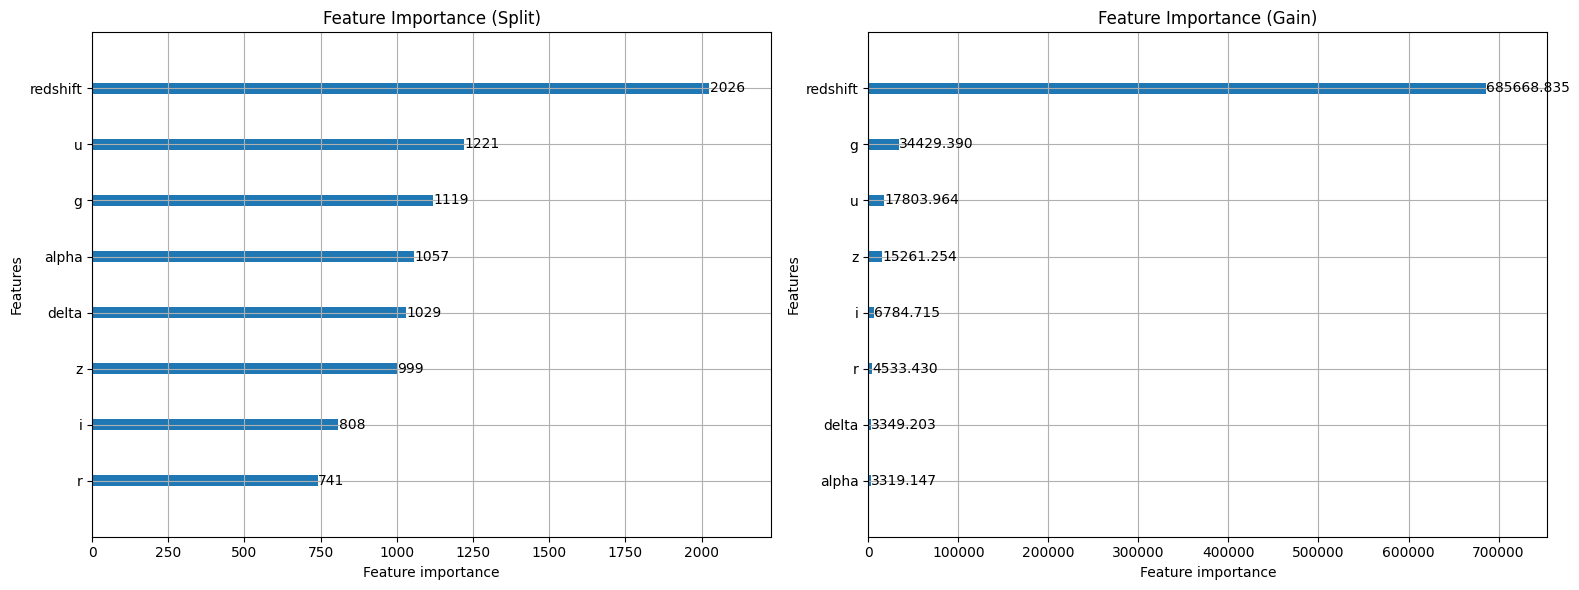


--- 변수 중요도 (Split 기준) ---
    Feature  Importance_Gain
7  redshift             2026
2         u             1221
3         g             1119
0     alpha             1057
1     delta             1029
6         z              999
5         i              808
4         r              741

--- 변수 중요도 (Gain 기준) ---
    Feature  Importance_Gain
7  redshift    685668.835346
3         g     34429.390383
2         u     17803.963998
6         z     15261.254254
5         i      6784.715425
4         r      4533.429896
1     delta      3349.203000
0     alpha      3319.147258


In [99]:
# 선정된 Best 모델(LGBM)을 전체 훈련 데이터로 재학습
best_model = models["LightGBM"]
best_model.fit(X_train, y_train)

# 시각화
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
# 왼쪽: Split (변수 사용 횟수)
plot_importance(best_model, importance_type='split', ax=ax[0], title='Feature Importance (Split)')
# 오른쪽: Gain (변수가 오차 감소에 기여한 정도 - 물리적 중요도)
plot_importance(best_model, importance_type='gain', ax=ax[1], title='Feature Importance (Gain)')
plt.tight_layout()
plt.show()

# 데이터프레임으로 수치 확인
ft_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance_Gain': best_model.feature_importances_
}).sort_values(by='Importance_Gain', ascending=False)

print("\n--- 변수 중요도 (Split 기준) ---")
print(ft_df)

ft_df2 = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance_Gain': best_model.booster_.feature_importance(importance_type='gain')
}).sort_values(by='Importance_Gain', ascending=False)

print("\n--- 변수 중요도 (Gain 기준) ---")
print(ft_df2)

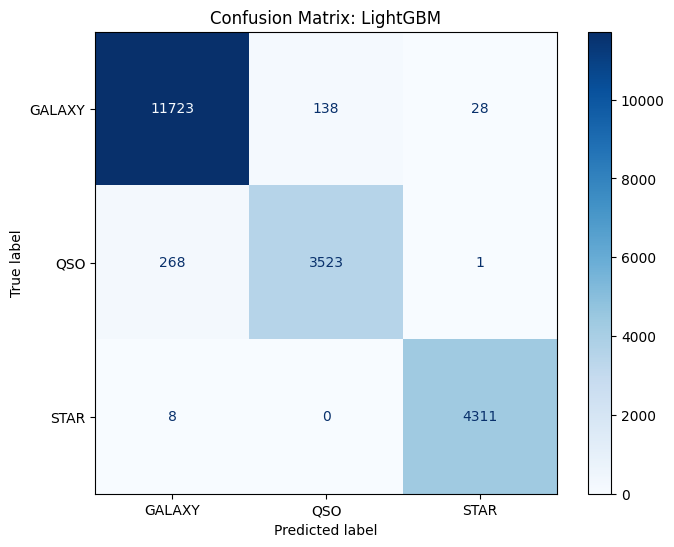

In [97]:
# 최종 선정된 LightGBM으로 예측값 생성
y_pred = best_model.predict(X_test)

# 혼동 행렬 생성
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

# 시각화
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title(f'Confusion Matrix: {best_model_name}')
plt.show()

In [98]:
# 클래스별 정밀도, 재현율, F1-score를 한눈에 확인
target_names = [str(c) for c in le.classes_]
print("출력될 클래스 이름:", target_names)

print(f"\n[ {best_model_name} 상세 분류 리포트 ]")
print(classification_report(y_test, y_pred, target_names=target_names))

출력될 클래스 이름: ['GALAXY', 'QSO', 'STAR']

[ LightGBM 상세 분류 리포트 ]
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98     11889
         QSO       0.96      0.93      0.95      3792
        STAR       0.99      1.00      1.00      4319

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000



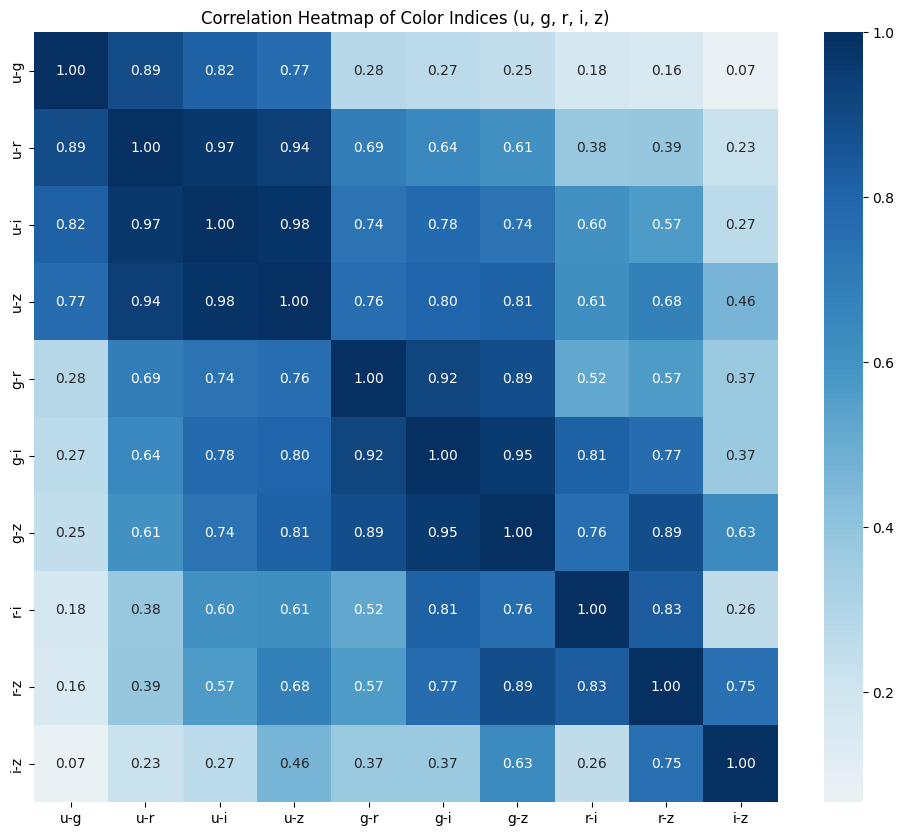

In [103]:
# 색지수 표 만들기
# 색지수 계산 (u-g, g-r, r-i, i-z 등 모든 조합)
filters = ['u', 'g', 'r', 'i', 'z']
color_df = pd.DataFrame()

for i in range(len(filters)):
    for j in range(i + 1, len(filters)):
        col_name = f"{filters[i]}-{filters[j]}"
        color_df[col_name] = df[filters[i]] - df[filters[j]]


# 상관계수 히트맵 그리기
plt.figure(figsize=(12, 10))
sns.heatmap(color_df.corr(), annot=True, cmap='RdBu', fmt=".2f", center=0)
plt.title("Correlation Heatmap of Color Indices (u, g, r, i, z)")
plt.show()

### --------------------------------------------
### <분석 리포트>

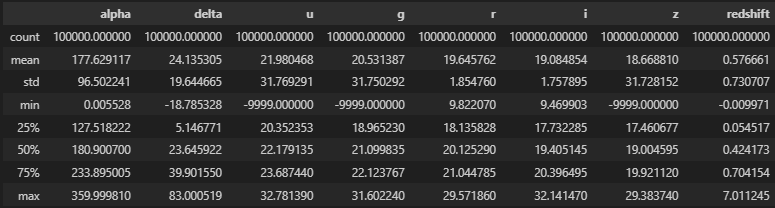

- descibe() 결과 u, g, z 열에 이상치 존재함을 확인하여 제거함 (-1 개)
- 총 9999행을 이용하여 계산

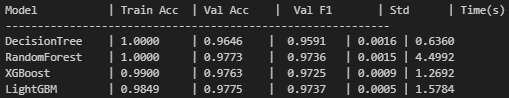

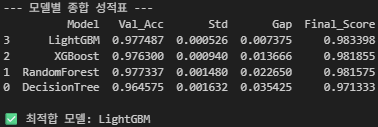

- 5-fold 교차검증을 수행함
- 각 모델별로 Train 정확도, Test 정확도, f1 스코어, 표준편차, 학습 시간을 계산하여 출력
- 기준은 정확도, 안정성(표준편차), Gap 순 (학습 시간의 차이는 RandomForest를 제외하고 크게 차이나지 않아 배제하였음)
- Gap 값을 통해 Train과 Validation 정확도의 차이가 얼마나 나는지 알 수 있음
- 모델별 학습 결과 LightGBM 모델이 최적합임을 확인

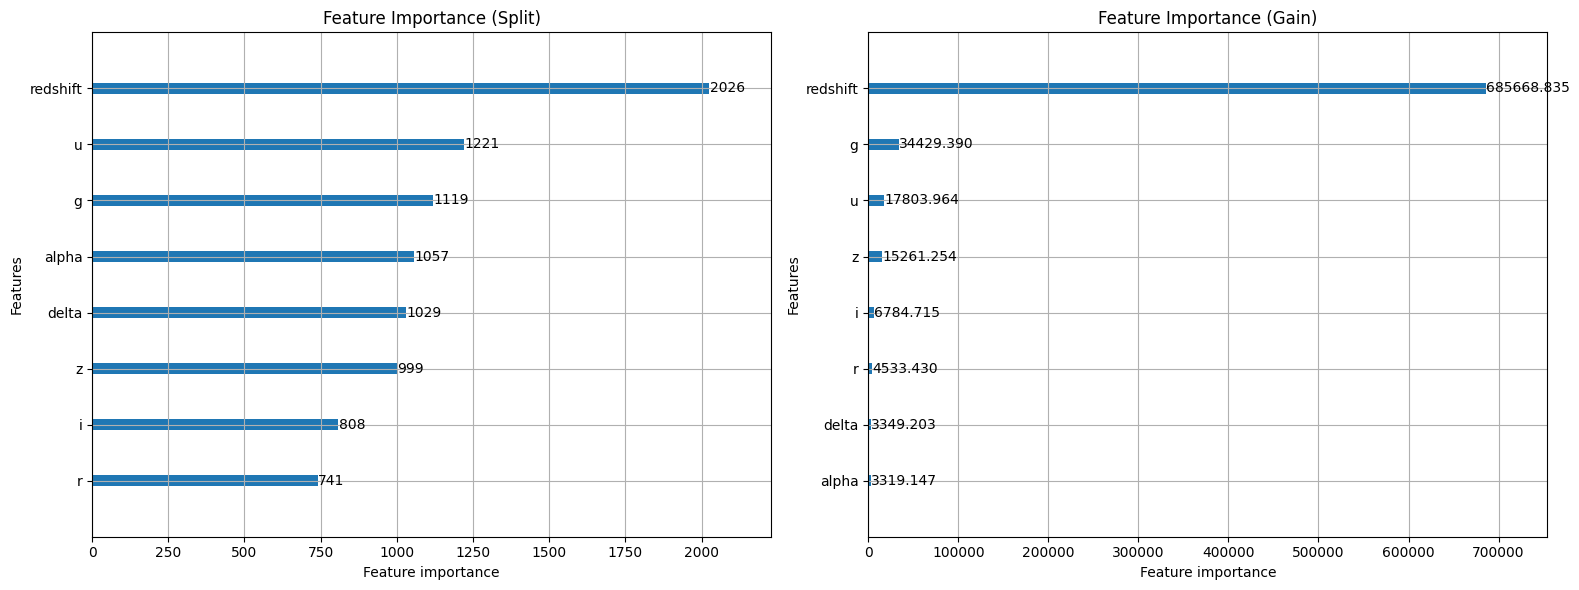

> 특성 중요도 분석(feature_importance) 표
- Gain 수치 기준으로 적색 편이(redshift)가 계산에 가장 많은 영향을 미쳤다고 판단, 다음 순서로 g, u, z, i, r
- 적색 편이 특성이 중요한 이유: 적색 편이가 커질수록 지구에서 별/은하/퀘이사가 멀리 있다(멀어지고 있다)고 판단

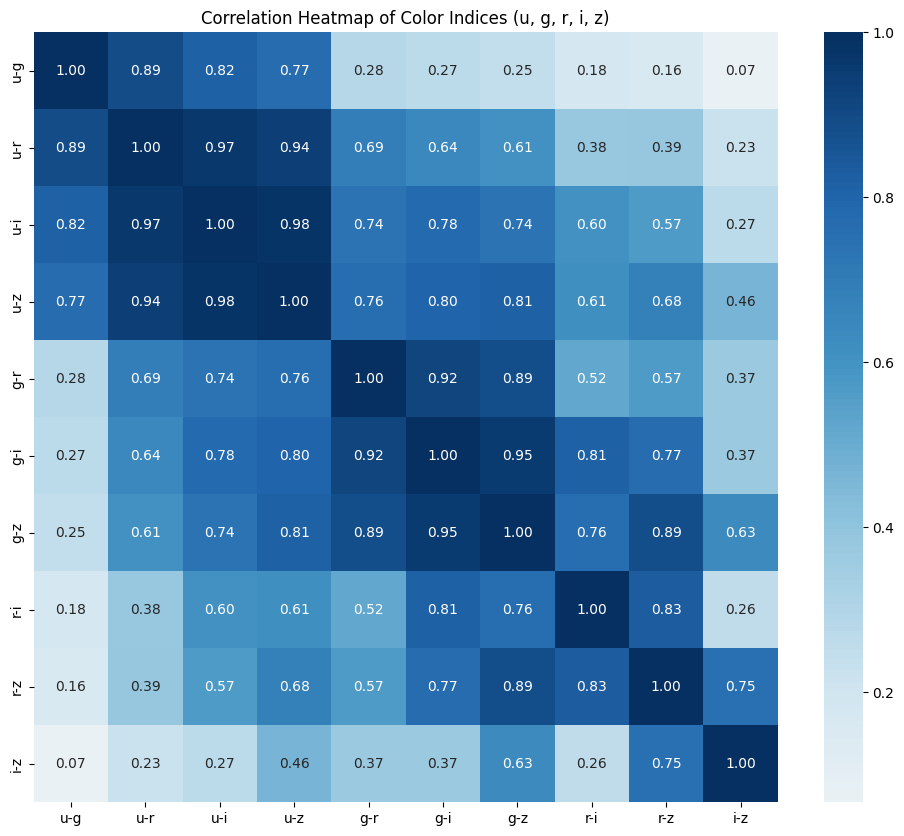

> 빛의 세기	u, g, r, i, z (자외선, 가시광선(녹), 가시광선(적), 근적외선, 적외선) 5가지 필터를 통과한 밝기
- 각 수치의 차(색지수)를 이용해 별의 색상 및 밝기 알 수 있음

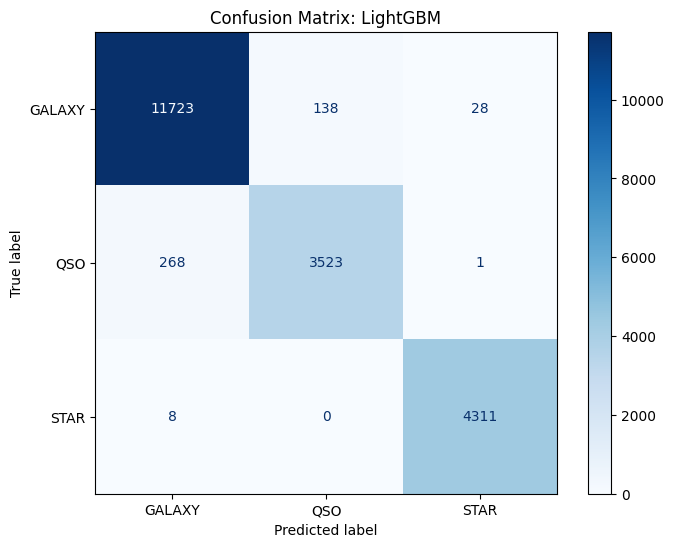

- LGBM 모델의 혼동행렬을 통해 각 데이터의 특징을 명확히 추출해 학습하였는지 확인
- 퀘이사를 은하로 헷갈려하는 케이스가 268건, 퀘이사를 은하로 헷갈려하는 케이스가 138건인 것을 보아 일반 은하와 퀘이사의 공통점에 의해 모델이 일부 헷갈려하기도 하였음을 알 수 있음
- 그러나 비율적으로 268 / 10만(약 0.002%), 138 / 10만(약 0.001%)의 확률이므로 무시할 수 있는 수준임

### --------------------------------------------